In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.add_dll_directory('C:\Aorda\PSG\lib')
import psgpython as psg

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from Subgradient import abs_calcfg, quadratic_calfg, abstwo_calfg, epsilon_svr_calcfg, nu_svr_calcfg, error_calcfg, cvaropt_calcfg, bad_quad_calcfg, pwl_calcfg, rozenbrock_calcfg
from Algorithms import ralgb5a, sualg, ralgb5a_m, sualg_m, proj_simplex

### Bad conditional convex quadratic functions from the book
f = sum(10**(i-1) * x[i-1]**2 for i in range(1, len(x)+1))

=================================== r - alg   ======================================================
itn    0  f    1.111100e+04  fr    1.111100e+04  nfg    1
itn   50  f   9.156446e-05  fr   2.561094e-05  nfg   70  lsa  69  lsm   3
Optimal solution: [-6.02871376e-06  2.21031025e-06  3.87002502e-07 -1.35022636e-07
  1.26251928e-09]
Final f(x): 1.184242488366465e-10
=================================== su - alg   ======================================================
itn    0  f    1.111100e+04  fr    1.111100e+04  nfg    1
itn   50  f   1.443976e+08  fr   9.201536e+02  nfg  120  lsa 119  lsm  16
itn  100  f   1.081230e+05  fr   9.201536e+02  nfg  202  lsa  82  lsm   7
itn  150  f   7.409140e+03  fr   9.201536e+02  nfg  298  lsa  96  lsm   8
itn  200  f   5.342698e+01  fr   3.756473e+01  nfg  392  lsa  94  lsm   9
itn  250  f   2.561056e+01  fr   2.509809e+01  nfg  500  lsa 108  lsm  15
itn  300  f   1.045076e+01  fr   1.045076e+01  nfg  606  lsa 106  lsm   6
itn  350  f   4.594948e+00  

(0.0, 150.0)

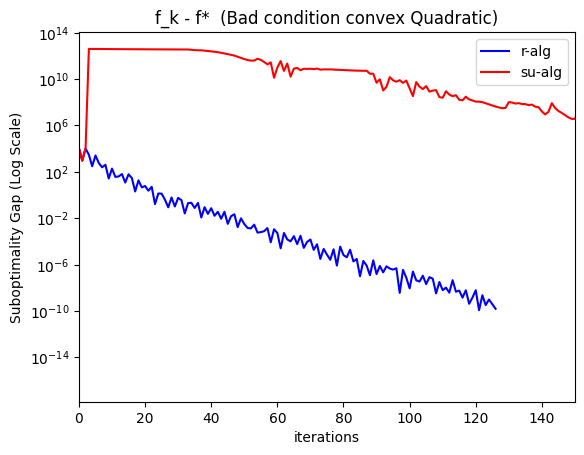

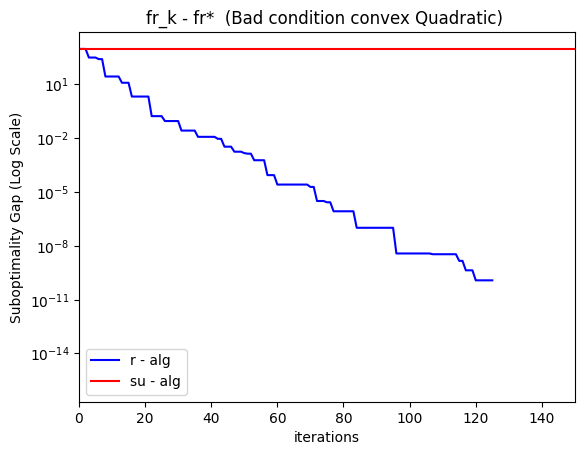

In [7]:
n = 5
x0 = np.ones(n)
print("=================================== r - alg   ======================================================")
xr_badquad_ralg, fr_badquad_ralg, itn_badquad_ralg, nfg_badquad_ralg, istop_badquad_ralg, h_badquad_ralg = ralgb5a(bad_quad_calcfg, x0,
    alpha = 2.0,                                                                                                               
    h0= 1.0,
    q1= 1,
    q2 = 1.1,
    nh = 3,
    epsg=1e-8,
    epsx=1e-5)
print("Optimal solution:", xr_badquad_ralg)
print("Final f(x):", fr_badquad_ralg)

print("=================================== su - alg   ======================================================")
xr_badquad_sualg, fr_badquad_sualg, itn_badquad_sualg, nfg_badquad_sualg, istop_badquad_sualg, h_badquad_sualg = sualg(bad_quad_calcfg, x0, theta = 0.5)
print("Optimal solution:", xr_badquad_sualg)
print("Final f(x):", fr_badquad_sualg)



# check the iteration perfromance of the r-alg  
plt.figure()
f_star = min(h_badquad_sualg['f'][-1], h_badquad_ralg['f'][-1])
plt.plot(h_badquad_ralg['f'] - f_star, color = "blue", label="r-alg")  # fk - f*
plt.plot(h_badquad_sualg['f'] -f_star, color = "red", label="su-alg" ) 
plt.title('f_k - f*  (Bad condition convex Quadratic)')
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel('Suboptimality Gap (Log Scale)')
plt.legend()
#plt.ylim((1e-5,1))
plt.xlim((0,150))

plt.figure()
#plot the fr 
fr_star =  min(h_badquad_sualg['fr(local opt)'][-1], h_badquad_ralg['fr(local opt)'][-1])
plt.plot(h_badquad_ralg['fr(local opt)'] - fr_star, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_badquad_sualg['fr(local opt)'] -fr_star, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (Bad condition convex Quadratic) ')
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel('Suboptimality Gap (Log Scale)')
plt.legend()
#plt.ylim((1e-5,1))
plt.xlim((0,150))

### convex piece-wise linear functions (Sabs)
f = np.sum(10**(i-1) * abs(x[i]) for i in range(1, len(x)+1))

=================================== r - alg   ======================================================
itn    0  f    1.111111e+09  fr    1.111111e+09  nfg    1
itn   50  f   1.165998e+03  fr   1.165998e+03  nfg   84  lsa  83  lsm   5
itn  100  f   2.971683e+00  fr   2.971683e+00  nfg  219  lsa 135  lsm  17
itn  150  f   3.036798e-03  fr   3.036798e-03  nfg  346  lsa 127  lsm  23
itn  200  f   9.145777e-07  fr   7.298364e-07  nfg  415  lsa  69  lsm   3
Optimal solution: [-1.31224265e-09  1.55177464e-09  4.83501867e-10 -8.23439993e-11
 -8.04513487e-12  2.27338808e-13  2.58123008e-14 -1.52784328e-15
  7.91934712e-16 -5.21048413e-17]
Final f(x): 4.2309845068394127e-07
=================================== su - alg   ======================================================
itn    0  f    1.111111e+09  fr    1.111111e+09  nfg    1
itn   50  f   9.428573e+19  fr   1.060733e+08  nfg  103  lsa 102  lsm  10
itn  100  f   6.730374e+23  fr   1.060733e+08  nfg  213  lsa 110  lsm  13
itn  150  f   1.0855

(0.0, 200.0)

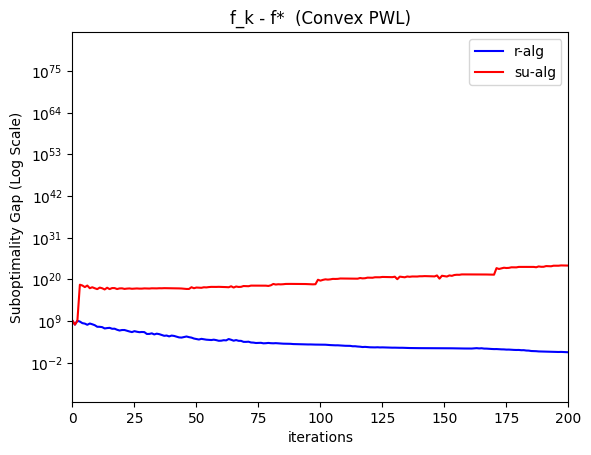

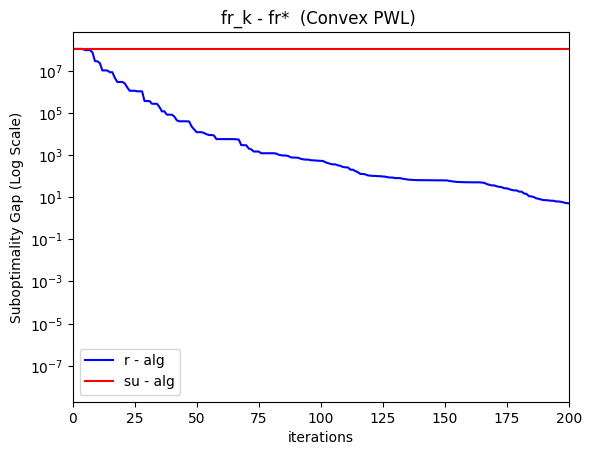

In [17]:
n = 10
x0 = np.ones(n)
print("=================================== r - alg   ======================================================")
xr_pwl_ralg, fr_pwl_ralg, itn_pwl_ralg, nfg_pwl_ralg, istop_pwl_ralg, h_pwl_ralg = ralgb5a(pwl_calcfg, x0)
print("Optimal solution:", xr_pwl_ralg)
print("Final f(x):", fr_pwl_ralg)

print("=================================== su - alg   ======================================================")
xr_pwl_sualg, fr_pwl_sualg, itn_pwl_sualg, nfg_pwl_sualg, istop_pwl_sualg, h_pwl_sualg = sualg(pwl_calcfg, x0,                                                                                          
    h0=1,
    q1=0.5,
    q2=2,
    nh=2,
    epsg=1e-8,
    epsx=1e-5,
    theta=0.9)
print("Optimal solution:", xr_pwl_sualg)
print("Final f(x):", fr_pwl_sualg)



# check the iteration perfromance of the r-alg  
plt.figure()
f_star = min(h_pwl_sualg['f'][-1], h_pwl_ralg['f'][-1])
plt.plot(h_pwl_ralg['f'] - f_star, color = "blue", label="r-alg")  # fk - f*
plt.plot(h_pwl_sualg['f'] -f_star, color = "red", label="su-alg" ) 
plt.title('f_k - f*  (Convex PWL)')
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel('Suboptimality Gap (Log Scale)')
plt.legend()
#plt.ylim((1e-8,1))
plt.xlim((0,200))

plt.figure()
#plot the fr 
fr_star =  min(h_pwl_sualg['fr(local opt)'][-1], h_pwl_ralg['fr(local opt)'][-1])
plt.plot(h_pwl_ralg['fr(local opt)'] - fr_star, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_pwl_sualg['fr(local opt)'] -fr_star, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (Convex PWL) ')
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel('Suboptimality Gap (Log Scale)')
plt.legend()
#plt.ylim((1e-8,1))
plt.xlim((0,200))

### Rozenbrock function from book

=================================== r - alg   ======================================================
itn    0  f    2.000000e+01  fr    2.000000e+01  nfg    1
itn   50  f   2.151695e-02  fr   2.145348e-02  nfg  120  lsa 119  lsm   7
itn  100  f   7.634446e-04  fr   7.559673e-04  nfg  331  lsa 211  lsm  21
itn  150  f   8.235025e-09  fr   8.235025e-09  nfg  523  lsa 192  lsm   8
Optimal solution: [0.99999267 0.99998599 0.99997098 0.99994136 0.9998833 ]
Final f(x): 2.660126545287029e-10
=================================== su - alg   ======================================================
itn    0  f    2.000000e+01  fr    2.000000e+01  nfg    1
itn   50  f   4.585348e-01  fr   4.399257e-01  nfg   67  lsa  66  lsm   2
itn  100  f   3.483740e-02  fr   3.443646e-02  nfg  156  lsa  89  lsm   2
itn  150  f   7.808311e-03  fr   7.708165e-03  nfg  254  lsa  98  lsm   3
itn  200  f   1.275362e-03  fr   1.253488e-03  nfg  354  lsa 100  lsm   2
itn  250  f   5.957492e-05  fr   5.853694e-05  nfg  45

(0.0, 200.0)

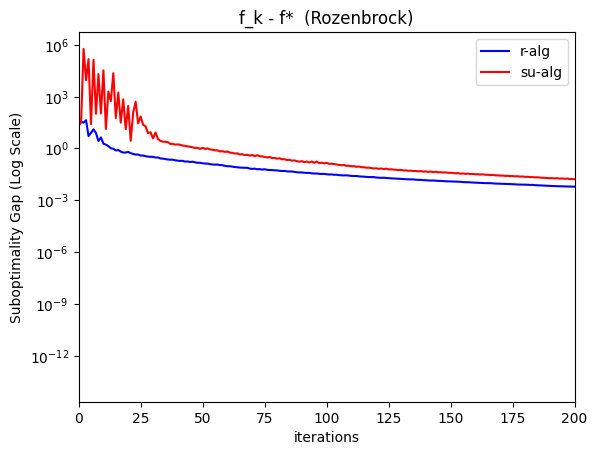

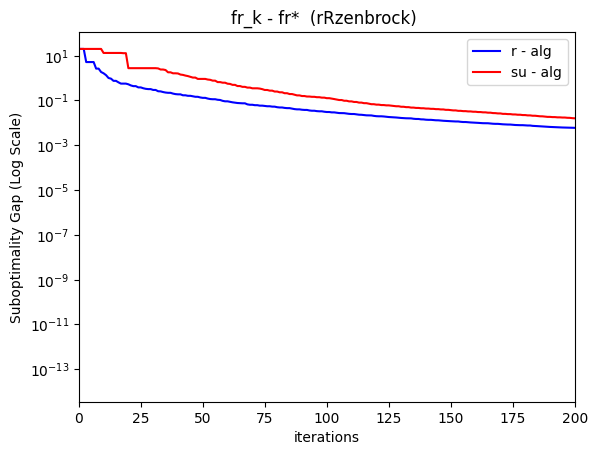

In [15]:
n = 5
x0 = np.zeros(n)
x0[0] = -1.0
for i in range(1, n):
    x0[i] = x0[i-1]**2 - 0.2
    
print("=================================== r - alg   ======================================================")
xr_rozenbrock_ralg, fr_rozenbrock_ralg, itn_rozenbrock_ralg, nfg_rozenbrock_ralg, istop_rozenbrock_ralg, h_rozenbrock_ralg = ralgb5a(rozenbrock_calcfg, x0,
    alpha = 2.0,                                                                                                               
    h0= 1.0,
    q1= 0.9,
    q2 = 1.1,
    nh = 3,
    epsg=1e-8,
    epsx=1e-5)
print("Optimal solution:", xr_rozenbrock_ralg)
print("Final f(x):", fr_rozenbrock_ralg)

print("=================================== su - alg   ======================================================")
xr_rozenbrock_sualg, fr_rozenbrock_sualg, itn_rozenbrock_sualg, nfg_rozenbrock_sualg, istop_rozenbrock_sualg, h_rozenbrock_sualg = sualg(rozenbrock_calcfg, x0,                                                                                          
    h0=1,
    q1=0.9,
    q2=1.1,
    nh=3,
    epsg=1e-8,
    epsx=1e-5,
    theta=0.1)
print("Optimal solution:", xr_rozenbrock_sualg)
print("Final f(x):", fr_rozenbrock_sualg)



# check the iteration perfromance of the r-alg  
plt.figure()
f_star = min(h_rozenbrock_sualg['f'][-1], h_rozenbrock_ralg['f'][-1])
plt.plot(h_rozenbrock_ralg['f'] - f_star, color = "blue", label="r-alg")  # fk - f*
plt.plot(h_rozenbrock_sualg['f'] -f_star, color = "red", label="su-alg" ) 
plt.title('f_k - f*  (Rozenbrock)')
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel('Suboptimality Gap (Log Scale)')
plt.legend()
#plt.ylim((1e-8,1))
plt.xlim((0,200))

plt.figure()
#plot the fr 
fr_star =  min(h_rozenbrock_sualg['fr(local opt)'][-1], h_rozenbrock_ralg['fr(local opt)'][-1])
plt.plot(h_rozenbrock_ralg['fr(local opt)'] - fr_star, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_rozenbrock_sualg['fr(local opt)'] -fr_star, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (rRzenbrock) ')
plt.yscale('log')
plt.xlabel('iterations')
plt.ylabel('Suboptimality Gap (Log Scale)')
plt.legend()
#plt.ylim((1e-8,1))
plt.xlim((0,200))

### Tesing Quad & Abs

************************************  Quadratic *****************************************
=================================== r - alg   ======================================================
itn    0  f    5.000000e+00  fr    5.000000e+00  nfg    1
Optimal solution: [2.68094430e-09 1.38669454e-09]
Final f(x): 1.9947963730559877e-16
=================================== su - alg   ======================================================
itn    0  f    5.000000e+00  fr    5.000000e+00  nfg    1
itn   50  f   2.042115e-04  fr   2.042115e-04  nfg   52  lsa  51  lsm   2
itn  100  f   1.128785e-09  fr   7.911333e-14  nfg  103  lsa  51  lsm   2
itn  150  f   9.400860e-15  fr   4.468629e-16  nfg  159  lsa  56  lsm   2
 Optimal solution: [2.13757618e-10 3.34707033e-10]
Final f(x): 1.1248572131029582e-17
Absolute Diff 1.8823106517456918e-16
     Gap  r-alg  su-alg
0  10^-1     10      25
1  10^-2     10      35
2  10^-3     18      45
3  10^-4     21      55
4  10^-5     24      63
5  10^-6     26  

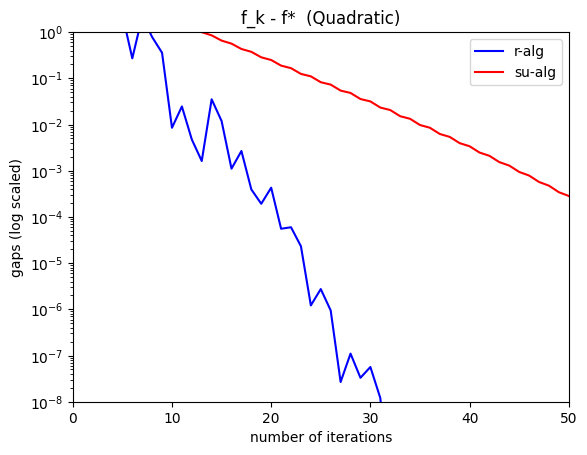

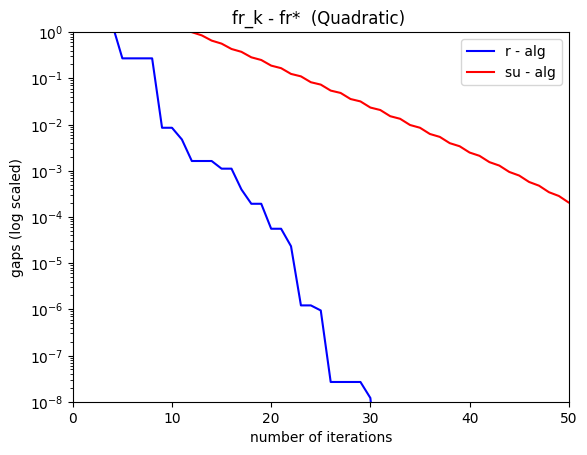

In [3]:
x0 = np.array([1, 0.2])
print("************************************  Quadratic *****************************************")
print("=================================== r - alg   ======================================================")
xr_quad_ralg, fr_quad_ralg, itn_quad_ralg, nfg_quad_ralg, istop_quad_ralg, h_quad_ralg = ralgb5a(quadratic_calfg, x0)
print("Optimal solution:", xr_quad_ralg)
print("Final f(x):", fr_quad_ralg)
print("=================================== su - alg   ======================================================")
xr_quad_sualg, fr_quad_sualg, itn_quad_sualg, nfg_quad_sualg, istop_quad_sualg, h_quad_sualg = sualg(quadratic_calfg,x0, theta=0.005)
print(" Optimal solution:", xr_quad_sualg)
print("Final f(x):", fr_quad_sualg)

# check the iteration perfromance of the r-alg  
plt.figure()
f_star =  min(h_quad_sualg['f'][-1], h_quad_ralg['f'][-1])
plt.plot(h_quad_ralg['f'] - f_star, color = "blue", label="r-alg")  # fk - f*
plt.plot(h_quad_sualg['f'] -f_star, color = "red", label="su-alg" ) 
plt.title('f_k - f*  (Quadratic)')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-8,1))
plt.xlim((0,50))

plt.figure()
#plot the fr 
fr_star =  min(h_quad_sualg['fr(local opt)'][-1], h_quad_ralg['fr(local opt)'][-1])
plt.plot(h_quad_ralg['fr(local opt)'] - fr_star, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_quad_sualg['fr(local opt)'] -fr_star, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (Quadratic) ')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-8,1))
plt.xlim((0,50))

# check which alg gives the smallest value, 
absdiff = np.abs(fr_quad_sualg - fr_quad_ralg)
print("Absolute Diff", absdiff)



def first_hit_iteration(fr_hist, f_star, thresholds):
    fr_hist = np.array(fr_hist)
    gaps = fr_hist - f_star

    hits = []
    for t in thresholds:
        idx = np.where(gaps <= t)[0]
        if len(idx) == 0:
            hits.append(None)   # 或者 np.nan, 或者 "-"
        else:
            hits.append(int(idx[0]))   # 第一次达到该 gap 的 iteration
    return hits



thresholds = [10**(-k) for k in range(1, 9)]
gap_labels = [f"10^-{k}" for k in range(1, 9)]



f_star = min(h_quad_ralg['f'][-1], h_quad_sualg['f'][-1])
ralg_hits_quad = first_hit_iteration(h_quad_ralg['f'], f_star, thresholds)
sualg_hits_quad = first_hit_iteration(h_quad_sualg['f'], f_star, thresholds)

table_gap_quad = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_quad,
    "su-alg": sualg_hits_quad
})

print(table_gap_quad)


f_star_local = min(h_quad_ralg['fr(local opt)'][-1], h_quad_sualg['fr(local opt)'][-1])
ralg_hits_local_quad = first_hit_iteration(h_quad_ralg['fr(local opt)'], f_star_local, thresholds)
sualg_hits_local_quad = first_hit_iteration(h_quad_sualg['fr(local opt)'], f_star_local, thresholds)

table_gap_local_quad = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_local_quad,
    "su-alg": sualg_hits_local_quad
})

print(table_gap_local_quad)


************************************  Abs *****************************************
=================================== r - alg   ======================================================
itn    0  f    3.000000e+00  fr    3.000000e+00  nfg    1
Optimal solution: [-7.16450608e-10  2.74479079e-10]
Final f(x): 3.4612413983300493e-09
=================================== su - alg   ======================================================
itn    0  f    3.000000e+00  fr    3.000000e+00  nfg    1
itn   50  f   1.992155e-02  fr   3.605426e-04  nfg   63  lsa  62  lsm   2
itn  100  f   1.623016e-02  fr   7.139041e-06  nfg  142  lsa  79  lsm   2
itn  150  f   1.468588e-02  fr   5.622304e-06  nfg  242  lsa 100  lsm   2
itn  200  f   9.545092e-03  fr   4.354838e-06  nfg  340  lsa  98  lsm   2
itn  250  f   1.750345e-04  fr   1.731393e-06  nfg  402  lsa  62  lsm   2
itn  300  f   8.602426e-06  fr   1.214513e-08  nfg  474  lsa  72  lsm   2
itn  350  f   7.783358e-06  fr   1.134067e-08  nfg  574  lsa 100  

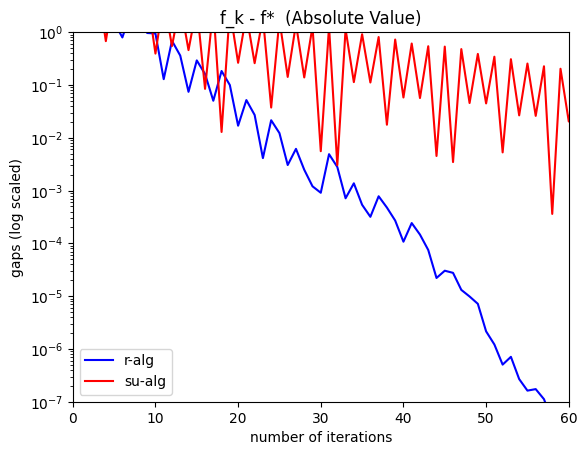

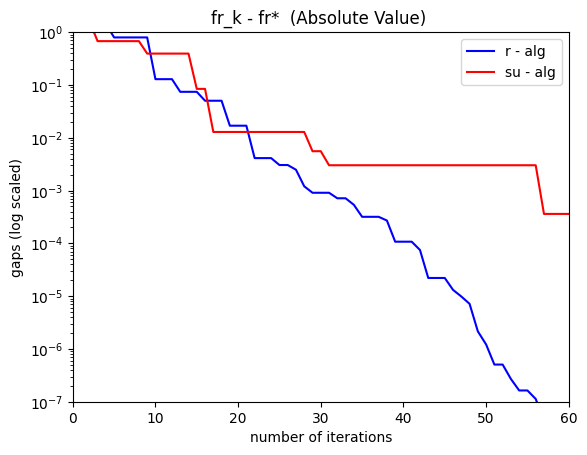

In [4]:
print("************************************  Abs *****************************************")
print("=================================== r - alg   ======================================================")
xr_abs_ralg, fr_abs_ralg, itn_abs_ralg, nfg_abs_ralg, istop_abs_ralg, h_abs_ralg = ralgb5a(abstwo_calfg,x0)
print("Optimal solution:", xr_abs_ralg)
print("Final f(x):", fr_abs_ralg)

print("=================================== su - alg   ======================================================")
xr_abs_sualg, fr_abs_sualg, itn_abs_sualg, nfg_abs_sualg, istop_abs_sualg, h_abs_sualg = sualg(abstwo_calfg, x0, theta = 0.001)
print(" Optimal solution:", xr_abs_sualg)
print("Final f(x):", fr_abs_sualg)

# check the iteration perfromance of the r-alg  
plt.figure()
f_star_abs =  min(h_abs_sualg['f'][-1], h_abs_ralg['f'][-1])
plt.plot(h_abs_ralg['f'] - f_star_abs, color = "blue", label="r-alg")  # fk - f*
plt.plot(h_abs_sualg['f'] -f_star_abs, color = "red", label="su-alg" ) 
plt.title('f_k - f*  (Absolute Value)')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-7,1))
plt.xlim((0,60))

plt.figure()
#plot the fr 
fr_star_abs =  min(h_abs_sualg['fr(local opt)'][-1], h_abs_ralg['fr(local opt)'][-1])
plt.plot(h_abs_ralg['fr(local opt)'] - fr_star_abs, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_abs_sualg['fr(local opt)'] -fr_star_abs, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (Absolute Value) ')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-7,1))
plt.xlim((0,60))

# check which alg gives the smallest value, 
absdiff = np.abs(fr_abs_sualg - fr_abs_ralg)
print("Absolute Diff", absdiff)


thresholds = [10**(-k) for k in range(1, 9)]
gap_labels = [f"10^-{k}" for k in range(1, 9)]



f_star = min(h_abs_ralg['f'][-1], h_abs_sualg['f'][-1])
ralg_hits_abs = first_hit_iteration(h_abs_ralg['f'], f_star, thresholds)
sualg_hits_abs = first_hit_iteration(h_abs_sualg['f'], f_star, thresholds)

table_gap_abs = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_abs,
    "su-alg": sualg_hits_abs
})

print(table_gap_abs)


f_star_local = min(h_abs_ralg['fr(local opt)'][-1], h_abs_sualg['fr(local opt)'][-1])
ralg_hits_local_abs = first_hit_iteration(h_abs_ralg['fr(local opt)'], f_star_local, thresholds)
sualg_hits_local_abs = first_hit_iteration(h_abs_sualg['fr(local opt)'], f_star_local, thresholds)

table_gap_local_abs = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_local_abs,
    "su-alg": sualg_hits_local_abs
})

print(table_gap_local_abs)


### Testing epsilon-SVR

In [10]:
# testing on epsilon-SVR
# Simulating Data
N = 5000
d = 10
np.random.seed(1)

X_raw = np.random.uniform(-1,1, size=(N,d))
e = np.random.laplace(0, 1, N)
w_true = np.ones(d)
y = X_raw @ w_true + e

X_alg = np.column_stack((np.ones(N), X_raw))  
w0 = np.zeros(d + 1)

# shared model parameters
eps = 0.05
lam = 1 / (2 * N)          # for Python objective
c = 1
reg = 1 / (2 * c * N)      # for PSG quadratic term

# testing on epsilon-SVR
calcfg = lambda w: epsilon_svr_calcfg(w, X_alg, y, eps, lam, 2) # if using l2 penalty
print("************************************ Epsilon -SVR *****************************************")
print("=================================== r - alg  L2 Penalty ======================================================")
xr_eps2_ralg, fr_eps2_ralg, itn_eps2_ralg, nfg_eps2_ralg, istop_eps2_ralg, h_eps2_ralg = ralgb5a(
    calcfg,
    w0,
    intp = 30
   
)
print("Optimal solution:", xr_eps2_ralg)
print("Final f(x):", fr_eps2_ralg)

print("=================================== su - alg  L2 Penalty ======================================================")

# testing on epsilon-SVR
calcfg = lambda w: epsilon_svr_calcfg(w, X_alg, y, eps, lam, 2) # if using l2 penalty
xr_eps2_sualg, fr_eps2_sualg, itn_eps2_sualg, nfg_eps2_sualg, istop_eps2_sualg, h_eps2_sualg = sualg(
    calcfg,
    w0, intp = 30
)

print(" Optimal solution:", xr_eps2_sualg)
print("Final f(x):", fr_eps2_sualg)




# Building Design Matrices
matrix_scenarios_body = np.asarray(X_raw, order='C')
scenario_benchmark = y 
x1 = np.reshape(np.ones(N), (N, 1))  # vector of ones
matrix_scenarios_body = np.column_stack((x1, matrix_scenarios_body, scenario_benchmark))
header_primal = ["x%d" % (i) for i in range(1, matrix_scenarios_body.shape[1])] # generate the title name x1, x2, ... x10
matrix_scenarios = [header_primal+['scenario_benchmark'], matrix_scenarios_body]  # combined title x1,x2...x10, scenario_benchmark with data

# Regularization Matrix
matrix_quadratic_body = np.asarray(reg * np.eye(d), order='C') # create identity matrix  10*10 * reg
matrix_quadratic = [header_primal[1:], matrix_quadratic_body]  #give titles 

# e-SVR Problem Statement (will need to add str(reg) in the problem statement
allowExternal = True
suppressMessages = False
problem_name = "problem_pm_reg"
problem_statement = "minimize\n\
pm_pen(" + "%f" % (eps) + ",abs(matrix_scenarios))\n\
+quadratic(matrix_quadratic)\n\
Value: \n\
pr_pen(" + "%f" % (eps) + ",abs(matrix_scenarios))\n\
Solver: BULDOZER, precision = 9"
problem_dictionary_pm_reg = {'problem_name': problem_name, 'problem_statement': problem_statement,
                             'matrix_scenarios': matrix_scenarios, 'matrix_quadratic': matrix_quadratic}


# Optimization Output
res_espilon_psg = psg.psg_solver(problem_dictionary_pm_reg, allowExternal, suppressMessages)

# objective
fr_espilon_psg = float(res_espilon_psg['output'][3].split()[3])

# Solution

primal_w_esplion_psg= res_espilon_psg['point_problem_1'][1][1:]
print("=================================== PSG L2 Penalty ======================================================")
print(f'PSG Results: \n w = {primal_w_esplion_psg}, fr = {fr_espilon_psg}')


************************************ Epsilon -SVR *****************************************
=================================== r - alg  L2 Penalty ======================================================
itn    0  f    1.759608e+00  fr    1.759608e+00  nfg    1
itn   30  f   9.257144e-01  fr   9.256971e-01  nfg   47  lsa  46  lsm   4
itn   60  f   9.256774e-01  fr   9.256774e-01  nfg   82  lsa  35  lsm   2
itn   90  f   9.256774e-01  fr   9.256774e-01  nfg  131  lsa  49  lsm   5
itn  120  f   9.256774e-01  fr   9.256774e-01  nfg  188  lsa  57  lsm   4
Optimal solution: [0.01092073 0.97047724 0.98735716 0.99100563 1.00063979 1.04336375
 1.03077055 1.00682996 1.01003232 0.96627639 1.01107957]
Final f(x): 0.9256773698720009
=================================== su - alg  L2 Penalty ======================================================
itn    0  f    1.759608e+00  fr    1.759608e+00  nfg    1
itn   30  f   9.257524e-01  fr   9.257028e-01  nfg   34  lsa  33  lsm   4
itn   60  f   9.256789e-01

Absolute Diff 6.7621003241313815e-09
     Gap  r-alg  su-alg
0  10^-1      3       3
1  10^-2      9       7
2  10^-3     28      11
3  10^-4     39      29
4  10^-5     49      43
5  10^-6     55      62
6  10^-7     74      85
7  10^-8     94     117
     Gap  r-alg  su-alg
0  10^-1      2       2
1  10^-2      8       6
2  10^-3     27      10
3  10^-4     38      28
4  10^-5     48      42
5  10^-6     54      61
6  10^-7     73      84
7  10^-8     93     116


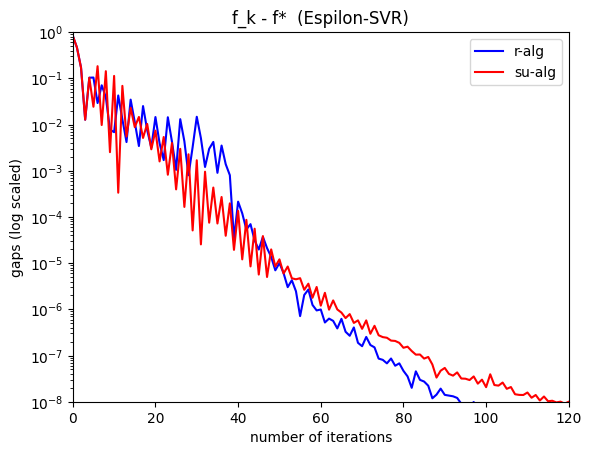

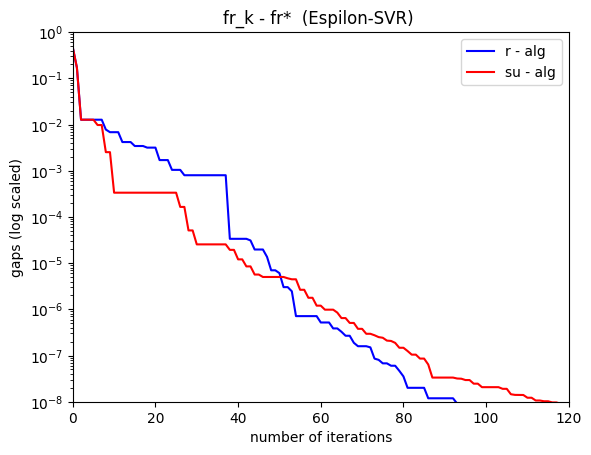

In [13]:
# check the iteration perfromance of the r-alg  (use the smallest f*, psg gives the worst fr in this case, r-alg is the smallest)
plt.figure()
f_star =  min(h_eps2_sualg['f'][-1], h_eps2_ralg['f'][-1])
plt.plot(h_eps2_ralg['f'] - f_star, color = "blue", label="r-alg")  # fk - f*
plt.plot(h_eps2_sualg['f'] -f_star, color = "red", label="su-alg" ) 
plt.title('f_k - f*  (Espilon-SVR)')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.yscale('log')
plt.legend()
plt.ylim((1e-8,1))
plt.xlim((0,120))


plt.figure()
#plot the fr (Don't know how to let PSG save the local opt fr)
fr_star =  min(h_eps2_sualg['fr(local opt)'][-1], h_eps2_ralg['fr(local opt)'][-1])
plt.plot(h_eps2_ralg['fr(local opt)'] - fr_star, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_eps2_sualg['fr(local opt)'] -fr_star, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (Espilon-SVR) ')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-8,1))
plt.xlim((0,120))

# check which alg gives the smallest value, check the abs diff of two algs  (r-alg is better in this case)
absdiff = np.abs(fr_eps2_sualg - fr_eps2_ralg)
print("Absolute Diff", absdiff)


thresholds = [10**(-k) for k in range(1, 9)]
gap_labels = [f"10^-{k}" for k in range(1, 9)]

f_star = min(h_eps2_ralg['f'][-1], h_eps2_sualg['f'][-1])
ralg_hits_eps2 = first_hit_iteration(h_eps2_ralg['f'], f_star, thresholds)
sualg_hits_eps2 = first_hit_iteration(h_eps2_sualg['f'], f_star, thresholds)

table_gap_eps2 = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_eps2,
    "su-alg": sualg_hits_eps2
})

print(table_gap_eps2)


f_star_local = min(h_eps2_ralg['fr(local opt)'][-1], h_eps2_sualg['fr(local opt)'][-1])
ralg_hits_local_eps2 = first_hit_iteration(h_eps2_ralg['fr(local opt)'], f_star_local, thresholds)
sualg_hits_local_eps2 = first_hit_iteration(h_eps2_sualg['fr(local opt)'], f_star_local, thresholds)

table_gap_local_eps2 = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_local_eps2,
    "su-alg": sualg_hits_local_eps2
})

print(table_gap_local_eps2)

### Testing Regression Error

In [11]:
# include PSG code in here to compare the diff 
# Simulating Data
N = 5000
d = 10
np.random.seed(1)
X = np.random.uniform(-1,1, size=(N,d)) # 1000 * 10 matrix
e = np.random.laplace(0, 1, N)  # Laplace Noise
w_true = np.ones(d)
y = X @ w_true + e
X = np.column_stack((np.ones(N), X))  

#Parameters
lam = 1/(2*N)
w0 = np.zeros(d + 1)

print("*****************************  Regression Error *****************************")
print("======================================== r - alg =================================================")
calcfg = lambda w: error_calcfg(w, X, y) 
xr_error_ralg, fr_error_ralg, itn_error_ralg, nfg_error_ralg, istop_error_ralg, h_error_ralg =  ralgb5a(
    calcfg,
    w0,
)

print("Optimal solution:", xr_error_ralg)
print("Final f(x):", fr_error_ralg)

print("======================================== su - alg =================================================")
calcfg = lambda w: error_calcfg(w, X, y) 
xr_error_sualg, fr_error_sualg, itn_error_sualg, nfg_error_sualg, istop_error_sualg, h_error_sualg = sualg(
    calcfg,
    w0,
    theta = 0.05
)
print("Optimal solution:", xr_error_sualg)
print("Final f(x):", fr_error_sualg)


#PSG code 
# Simulating Data
N = 5000
d = 10
np.random.seed(1)
X = np.random.uniform(-1,1, size=(N,d))
e = np.random.laplace(0, 1, N)  # Laplace Noise
w = np.ones(d)
b = np.zeros(N)
y = X@w + b  # y = x_1+..+x_10
# Model Parameters
c = 1
reg = 1/(2*c*N)

# Building Design Matrices
matrix_scenarios_body = np.asarray(X, order='C')
scenario_benchmark = y + e
x1 = np.reshape(np.ones(N), (N, 1))  # vector of ones
matrix_scenarios_body = np.column_stack((x1, matrix_scenarios_body, scenario_benchmark))
header_primal = ["x%d" % (i) for i in range(1, matrix_scenarios_body.shape[1])] # generate the title name x1, x2, ... x10
matrix_scenarios = [header_primal+['scenario_benchmark'], matrix_scenarios_body]  # combined title x1,x2...x10, scenario_benchmark with data

# Regularization Matrix
matrix_quadratic_body = np.asarray(reg * np.eye(d), order='C') # create identity matrix  10*10 * reg
matrix_quadratic = [header_primal[1:], matrix_quadratic_body]  #give titles 


allowExternal = True
suppressMessages = False
problem_name_l = "problem_linear"
problem_statement_l = "minimize\n\
variable(super_err)\n\
constraint: <= 0\n\
pm_pen_g(0,matrix_scenarios)\n\
-variable(super_err)\n\
constraint: <= 0\n\
pm_pen(0,matrix_scenarios)\n\
-variable(super_err)\n\
Solver: BULDOZER, precision = 9" 
problem_dictionary_linear = {'problem_name':problem_name_l, 
                                'problem_statement':problem_statement_l,
                                'matrix_scenarios':matrix_scenarios}


# Optimization Output
res_reg = psg.psg_solver(problem_dictionary_linear, allowExternal, suppressMessages)

# objective
fr_reg_psg = res_reg['point_problem_1'][1][0]

# Solution
primal_w_reg = res_reg['point_problem_1'][1][1:]
print(f'PSG Results: \n w = {primal_w_reg}, b = {primal_w_reg[0]}, fr = {fr_reg_psg}')

*****************************  Regression Error *****************************
======================================== r - alg =================================================
itn    0  f    9.045383e-01  fr    9.045383e-01  nfg    1
itn   50  f   4.869646e-01  fr   4.869645e-01  nfg   74  lsa  73  lsm   4
itn  100  f   4.869639e-01  fr   4.869639e-01  nfg  161  lsa  87  lsm  11
Optimal solution: [0.01323416 0.98582206 0.98349924 0.98681346 0.99719633 1.04459692
 1.02545592 1.01684848 1.01304293 0.96207816 1.00923157]
Final f(x): 0.4869638550765907
======================================== su - alg =================================================
itn    0  f    9.045383e-01  fr    9.045383e-01  nfg    1
itn   50  f   4.871526e-01  fr   4.871435e-01  nfg   74  lsa  73  lsm   2
itn  100  f   4.869641e-01  fr   4.869641e-01  nfg  127  lsa  53  lsm   2
itn  150  f   4.869639e-01  fr   4.869639e-01  nfg  179  lsa  52  lsm   2
itn  200  f   4.869639e-01  fr   4.869639e-01  nfg  229  lsa  50

Absolute Diff 6.318815515271581e-08
     Gap  r-alg  su-alg
0  10^-1      7     8.0
1  10^-2     11    16.0
2  10^-3     29    20.0
3  10^-4     44    76.0
4  10^-5     55    92.0
5  10^-6     64   108.0
6  10^-7     99   139.0
7  10^-8    136     NaN
     Gap  r-alg  su-alg
0  10^-1      6     7.0
1  10^-2     10    15.0
2  10^-3     28    19.0
3  10^-4     43    75.0
4  10^-5     54    91.0
5  10^-6     63   107.0
6  10^-7     98   138.0
7  10^-8    135     NaN


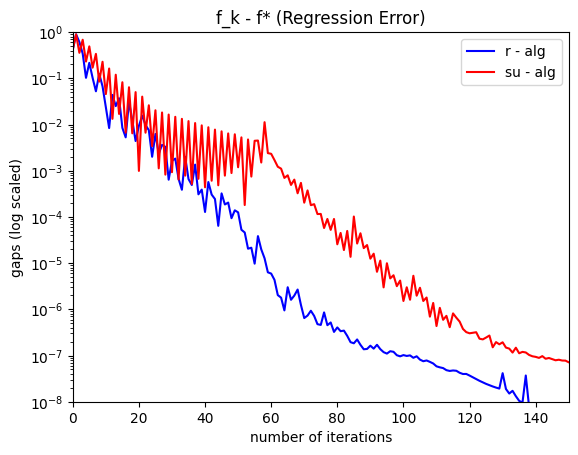

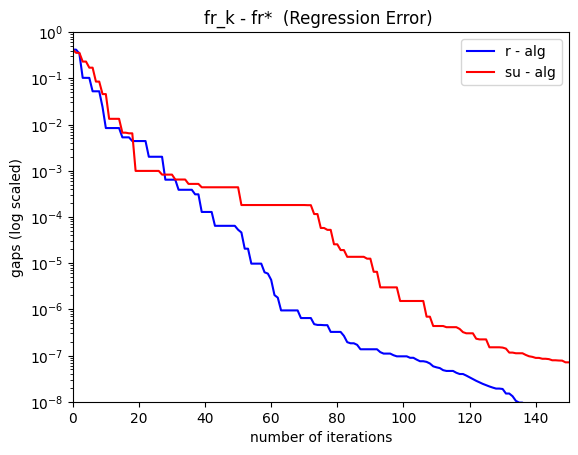

In [14]:
# check the iteration perfromance of the r-alg  
plt.figure()
f_star_error =  min(h_error_sualg['f'][-1], h_error_ralg['f'][-1])
plt.plot(h_error_ralg['f'] - f_star_error, color = "blue", label="r - alg")  # fk - f*
plt.plot(h_error_sualg['f'] - f_star_error, color = "red", label="su - alg" ) 
plt.title('f_k - f* (Regression Error)')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-8,1))
plt.xlim((0,150))



plt.figure()
#plot the fr (Don't know how to let PSG save the local opt fr)
fr_star_error =  min(h_error_sualg['fr(local opt)'][-1], h_error_ralg['fr(local opt)'][-1])
plt.plot(h_error_ralg['fr(local opt)'] - fr_star_error, color = "blue", label="r - alg")  # fr_k - fr*
plt.plot(h_error_sualg['fr(local opt)'] -fr_star_error, color = "red", label="su - alg" ) 
plt.title('fr_k - fr*  (Regression Error) ')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-8,1))
plt.xlim((0,150))



# check which alg gives the smallest value, check the abs diff of two algs  (r-alg is better in this case)
absdiff_error = np.abs(fr_error_sualg - fr_error_ralg)
print("Absolute Diff", absdiff_error)


thresholds = [10**(-k) for k in range(1, 9)]
gap_labels = [f"10^-{k}" for k in range(1, 9)]

f_star = min(h_error_ralg['f'][-1], h_error_sualg['f'][-1])
ralg_hits_error = first_hit_iteration(h_error_ralg['f'], f_star, thresholds)
sualg_hits_error = first_hit_iteration(h_error_sualg['f'], f_star, thresholds)

table_gap_error = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_error,
    "su-alg": sualg_hits_error
})

print(table_gap_error)


f_star_local = min(h_error_ralg['fr(local opt)'][-1], h_error_sualg['fr(local opt)'][-1])
ralg_hits_local_error = first_hit_iteration(h_error_ralg['fr(local opt)'], f_star_local, thresholds)
sualg_hits_local_error = first_hit_iteration(h_error_sualg['fr(local opt)'], f_star_local, thresholds)

table_gap_local_error = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_local_error,
    "su-alg": sualg_hits_local_error
})

print(table_gap_local_error)


### Testing on CVaR Portfolio Opt Problem

In [6]:
#Parameters
#PSG
# Simulating Data
N = 5000
d = 10
np.random.seed(1)
X = np.random.uniform(-1,1, size=(N,d))
e = np.random.laplace(0, 1, N)  # Laplace Noise
w = np.ones(d)
b = np.zeros(N)
y = X@w + b  # y = x_1+..+x_10
alpha = 0.95

lam = 1/(2*N)
# w0 = np.ones(d)
w0 = np.array([0.3, 1, 0.2, 0.1, 1, 0, 0, 0, 0, 0.2])
#w0 = [1,0,0,0,0,0,0,0,0,0]
print("************************** CVaR port Opt **************************")
print("======================================== r - alg =================================================")
calcfg = lambda w: cvaropt_calcfg(w, X, M=100) 
xr_cvaropt_ralg, fr_cvaropt_ralg, itn_cvaropt_ralg, nfg_cvaropt_ralg, istop_cvaropt_ralg, h_cvaropt_ralg =  ralgb5a(
    calcfg,
    w0,
    alpha=2.5,
    h0=1.0,
    q1=0.9,
    q2=1.2,
    epsg=1e-8,
    epsx=1e-8,
    maxitn=1000,
    intp=20,
 
)

print("Optimal solution:", xr_cvaropt_ralg)
print("Final f(x):", fr_cvaropt_ralg)

************************** CVaR port Opt **************************
======================================== r - alg =================================================
itn    0  f    1.677560e+00  fr    1.677560e+00  nfg    1
itn   20  f   4.137139e-01  fr   4.137139e-01  nfg   29  lsa  28  lsm   3
itn   40  f   3.744988e-01  fr   3.744988e-01  nfg   54  lsa  25  lsm   2
itn   60  f   3.744643e-01  fr   3.744643e-01  nfg   79  lsa  25  lsm   2
itn   80  f   3.744634e-01  fr   3.744634e-01  nfg  116  lsa  37  lsm   4
itn  100  f   3.744633e-01  fr   3.744633e-01  nfg  145  lsa  29  lsm   3
itn  120  f   3.744633e-01  fr   3.744633e-01  nfg  176  lsa  31  lsm   3
Optimal solution: [0.11139836 0.10394453 0.09143831 0.10066698 0.09071779 0.10844104
 0.07400312 0.09835066 0.10247435 0.11856485]
Final f(x): 0.37446325197276187


In [7]:
print("======================================== su - alg =================================================")
calcfg = lambda w: cvaropt_calcfg(w, X, M=10) 
xr_cvaropt_sualg, fr_cvaropt_sualg, itn_cvaropt_sualg, nfg_cvaropt_sualg, istop_cvaropt_sualg, h_cvaropt_sualg = sualg(
    calcfg,
    w0,
    theta=0.05,
    h0=1.0,
    q1=0.9,
    q2=1.2,
    epsg=1e-8,
    epsx=1e-8,
    maxitn=1000,
    intp=50,
)
print("Optimal solution:", xr_cvaropt_sualg)
print("Final f(x):", fr_cvaropt_sualg)

======================================== su - alg =================================================
itn    0  f    1.677560e+00  fr    1.677560e+00  nfg    1
itn   50  f   3.745591e-01  fr   3.742382e-01  nfg   67  lsa  66  lsm   3
itn  100  f   3.744642e-01  fr   3.742382e-01  nfg  120  lsa  53  lsm   2
itn  150  f   3.744634e-01  fr   3.742382e-01  nfg  175  lsa  55  lsm   2
itn  200  f   3.744634e-01  fr   3.742382e-01  nfg  229  lsa  54  lsm   2
Optimal solution: [0.11004455 0.10363854 0.09436702 0.09859877 0.0930173  0.10591935
 0.07514307 0.1003417  0.09934652 0.11880337]
Final f(x): 0.3742382379781963


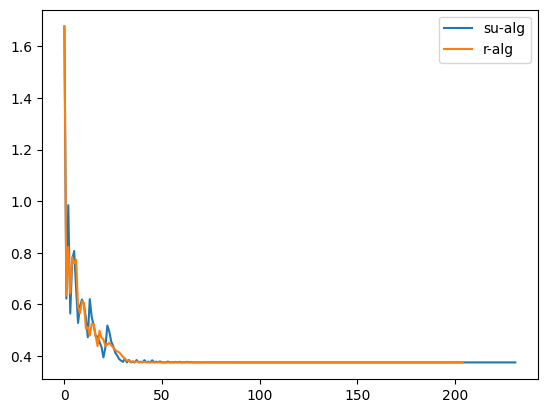

In [8]:
plt.plot(h_cvaropt_sualg['f'])
plt.plot(h_cvaropt_ralg['f'])
plt.legend(['su-alg', 'r-alg'])

In [13]:
#PSG
# Simulating Data
N = 5000
d = 10
np.random.seed(1)
X = np.random.uniform(-1,1, size=(N,d))
e = np.random.laplace(0, 1, N)  # Laplace Noise
w = np.ones(d)
b = np.zeros(N)
y = X@w + b  # y = x_1+..+x_10
alpha = 0.95

# Building Design Matrices
matrix_scenarios_body = np.asarray(X, order='C')
header_primal = ["x%d" % (i) for i in range(1,d+1)] # generate the title name x1, x2, ... x10
matrix_scenarios = [header_primal, matrix_scenarios_body]  # combined title x1,x2...x10, scenario_benchmark with data
matrix_linear = [header_primal, np.ones(d)]  # linear: x1 + x2 + ... + x10 = 1, give the title and the data

allowExternal = True
suppressMessages = False
problem_name = "problem_port"
problem_statement = "minimize\n\
cvar_risk(" + "%f" % (alpha) + ",matrix_scenarios)\n\
+avg(matrix_scenarios)\n\
constraint: = 1 \n\
linear(matrix_linear)\n\
Box:>=0\n\
Solver: BULDOZER, precision = 9"
problem_dictionary_port = {'problem_name': problem_name, 'problem_statement': problem_statement,
                             'matrix_scenarios': matrix_scenarios, 'matrix_linear': matrix_linear}


# Optimization Output
res_port = psg.psg_solver(problem_dictionary_port, allowExternal, suppressMessages)

# Solution
port_weights = res_port['point_problem_1'][1]
print(f'Optimal coefficients with PSG: \n w = {port_weights}')

cvar_objective = res_port['output'][3].split()[3]
print(f'CVaR objective value with PSG: {cvar_objective}')


Running solver
Reading problem formulation
Asking for data information
Getting data
     10.0% of scenarios is processed
100% of matrix_scenarios was read
100% of matrix_linear was read
Start optimization
Ext.iteration=1  Objective=0.398912773040E+00  Residual=0.580086940461E-01
Ext.iteration=29  Objective=0.374464097269E+00  Residual=0.750254066650E-07
Ext.iteration=39  Objective=0.374464097269E+00  Residual=0.750254066650E-07
Ext.iteration=47  Objective=0.374464097269E+00  Residual=0.750254066650E-07
Ext.iteration=60  Objective=0.374464097269E+00  Residual=0.750254066650E-07
Ext.iteration=117  Objective=0.374463290114E+00  Residual=0.548237455433E-09
Ext.iteration=121  Objective=0.374463290114E+00  Residual=0.548237455433E-09
Ext.iteration=124  Objective=0.374463290114E+00  Residual=0.548237455433E-09
Ext.iteration=127  Objective=0.374463290114E+00  Residual=0.548237455433E-09
Ext.iteration=216  Objective=0.374463251947E+00  Residual=0.445088410572E-12
Ext.iteration=220  Objective=0.

In [15]:
cvar_objective

'0.374463251947'

#### plot CVaR Port Opt

Absolute Diff 0.00022501399456559268
     Gap  r-alg  su-alg
0  10^-1     17      12
1  10^-2     32      29
2  10^-3     39      32
3  10^-4     48      32
4  10^-5     61      36
5  10^-6     80      36
6  10^-7    117      36
7  10^-8    134      36


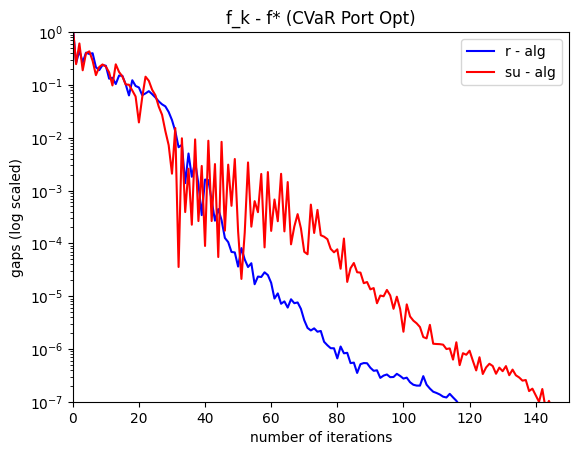

In [20]:
# check the iteration perfromance of the r-alg  
plt.figure()
f_star_cvaropt =  min(h_cvaropt_sualg['f'][-1], h_cvaropt_ralg['f'][-1])
#plt.plot(h_cvaropt_ralg['f'] - f_star_cvaropt, color = "blue", label="r - alg")  # fk - f*
plt.plot(np.abs(h_cvaropt_ralg['f'] - h_cvaropt_ralg['f'][-1]), color = "blue", label="r - alg")  # fk - f*


#plt.plot(h_cvaropt_sualg['f'] - f_star_cvaropt, color = "red", label="su - alg" ) 
plt.plot(np.abs(h_cvaropt_sualg['f'] - h_cvaropt_sualg['f'][-1]), color = "red", label="su - alg" ) 

plt.title('f_k - f* (CVaR Port Opt)')
plt.yscale('log')
plt.xlabel('number of iterations')
plt.ylabel('gaps (log scaled)')
plt.legend()
plt.ylim((1e-7,1))
plt.xlim((0,150))



# check the abs diff of two algs 
absdiff_cvaropt = np.abs(fr_cvaropt_sualg - fr_cvaropt_ralg)
print("Absolute Diff", absdiff_cvaropt)



thresholds = [10**(-k) for k in range(1, 9)]
gap_labels = [f"10^-{k}" for k in range(1, 9)]

f_star = min(h_cvaropt_ralg['f'][-1], h_cvaropt_sualg['f'][-1])
ralg_hits_cvaropt = first_hit_iteration(h_cvaropt_ralg['f'], f_star, thresholds)
sualg_hits_cvaropt = first_hit_iteration(h_cvaropt_sualg['f'], f_star, thresholds)

table_gap_cvaropt = pd.DataFrame({
    "Gap": gap_labels,
    "r-alg": ralg_hits_cvaropt,
    "su-alg": sualg_hits_cvaropt
})

print(table_gap_cvaropt)




# Save B memory analysis 
Testing on diff matrix of B and compare the diff 
From B = 10 * 1 to B = 10 * 10

In [2]:
# testing on epsilon-SVR
# Simulating Data
N = 5000
d = 10
np.random.seed(1)
X = np.random.uniform(-1,1, size=(N,d)) # 1000 * 10 matrix
e = np.random.laplace(0, 1, N)  # Laplace Noise
w_true = np.ones(d)
y = X @ w_true + e

X = np.column_stack((np.ones(N), X))  

#Parameters
lam = 1/(2*N)
eps = 2.921347634591
w0 = np.zeros(d + 1)

results_sualg_m = []
results_ralg_m  = []
k_range = np.arange(1,d+2)

for k in k_range:
    print(f"\n================ k = {k} ================\n")
    calcfg = lambda w: epsilon_svr_calcfg(w, X, y, eps, lam, 2) # if using l2 penalty
    # print("=================================== r - alg Save B  ======================================================")
    xr_eps1_ralg_m, fr_eps1_ralg_m, itn_eps1_ralg_m, nfg_eps1_ralg_m, istop_eps1_ralg_m, h_eps1_ralg_m = ralgb5a_m(
        calcfg,
        w0,
        epsx=1e-8,
        m = k
    
    )
    results_ralg_m.append({
        "k": k, 
        'xr': xr_eps1_ralg_m,
        "f": fr_eps1_ralg_m,
        "itn": itn_eps1_ralg_m,
        'istop': istop_eps1_ralg_m,
        "nfg": nfg_eps1_ralg_m,
    })

    # print("=================================== su - alg save B ======================================================")
    xr_eps1_sualg_m, fr_eps1_sualg_m, itn_eps1_sualg_m, nfg_eps1_sualg_m, istop_eps1_sualg_m, h_eps1_sualg_m = sualg_m(
        calcfg,
        w0,
        epsx=1e-8,
        m = k
    
    )
    results_sualg_m.append({
        "k": k, 
        'xr': xr_eps1_sualg_m,
        "f": fr_eps1_sualg_m,
        "itn": itn_eps1_sualg_m,
        'istop': istop_eps1_sualg_m, 
        "nfg": nfg_eps1_sualg_m,
    })
    


table_ralg_m= pd.DataFrame(results_ralg_m)[["k", "xr", "f", "itn", 'istop', "nfg"]]
table_sualg_m= pd.DataFrame(results_sualg_m)[["k", "xr", "f", "itn", 'istop', "nfg"]]


================ k = 1 ================

itn    0  f    2.208865e-01  fr    2.208865e-01  nfg    1
itn    0  f    2.208865e-01  fr    2.208865e-01  nfg    1
itn   50  f   6.995005e-02  fr   6.991369e-02  nfg   63  lsa  62  lsm   2
itn  100  f   6.991168e-02  fr   6.991166e-02  nfg  134  lsa  71  lsm   3
itn  150  f   6.991194e-02  fr   6.991133e-02  nfg  211  lsa  77  lsm   4
itn  200  f   6.991109e-02  fr   6.991107e-02  nfg  287  lsa  76  lsm   4
itn  250  f   6.991077e-02  fr   6.991077e-02  nfg  370  lsa  83  lsm   5
itn  300  f   6.991038e-02  fr   6.991036e-02  nfg  449  lsa  79  lsm   4
itn  350  f   6.991025e-02  fr   6.991024e-02  nfg  517  lsa  68  lsm   3
itn  400  f   6.991025e-02  fr   6.991024e-02  nfg  584  lsa  67  lsm   2
itn  450  f   6.991025e-02  fr   6.991024e-02  nfg  644  lsa  60  lsm   2

================ k = 2 ================

itn    0  f    2.208865e-01  fr    2.208865e-01  nfg    1
itn    0  f    2.208865e-01  fr    2.208865e-01  nfg    1
itn   50  f   5.06

In [3]:
table_ralg_m

,k,xr,f,itn,istop,nfg
0,1,"[0.7893095319913342, 0.7893095319913342, 0.789...",0.072850,25,3,49
1,2,"[0.06462275030855152, 1.020005687986803, 1.020...",0.050749,46,3,81
2,3,"[0.05894455293147983, 1.065794176876475, 1.017...",0.050705,64,3,104
3,4,"[0.05643019053556624, 1.0998422970443777, 0.96...",0.050634,83,3,135
4,5,"[0.06291257584193442, 1.0951109423488046, 0.97...",0.050535,91,3,136
5,6,"[0.06530506433161334, 1.0966634896991727, 0.97...",0.050520,106,3,161
6,7,"[0.06926385676526539, 1.0894884599999748, 0.96...",0.050485,100,3,133
7,8,"[0.07536793778805738, 1.098911526251581, 0.947...",0.050416,116,3,165
8,9,"[0.0745274139081131, 1.0983029822799588, 0.949...",0.050402,142,3,216
9,10,"[0.07933995345407692, 1.0984923893731946, 0.94...",0.050327,165,3,238


In [4]:
table_sualg_m

,k,xr,f,itn,istop,nfg
0,1,"[0.7571660460463101, 0.8218924583487476, 0.821...",0.069910,492,3,694
1,2,"[0.06332637657270634, 1.0400888624833795, 1.01...",0.050600,352,3,462
2,3,"[0.057898480657871766, 1.0823003049518092, 1.0...",0.050623,1000,4,1575
3,4,"[0.061003204516707966, 1.0990518253880759, 0.9...",0.050563,1000,4,1586
4,5,"[0.05449095349506338, 1.0589251171466827, 0.94...",0.050463,1000,4,1605
5,6,"[0.05606904524459982, 1.1004293161261258, 0.94...",0.050449,1000,4,1604
6,7,"[0.06486445881847772, 1.0063271974399466, 0.86...",0.050353,1000,4,1609
7,8,"[0.07393733365140297, 1.1031361405269717, 0.94...",0.050399,182,3,189
8,9,"[0.04649008952881851, 1.035581310234542, 0.888...",0.050267,1000,4,1620
9,10,"[0.07923929857016614, 1.0966706506927284, 0.94...",0.050322,183,3,190
